In [120]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import shap

In [5]:
df = pd.read_json("../data/supervise_myth_clusters.json", lines=True)
df.head()

,id,text,type,source,imdb_title,imdb_year,imdb_genres,inferred_media_type,combined_text,has_semantic_match,has_lexical_match,has_sentence_myth_trope_hit,max_trope_similarity,myth_hit_count,myth_theme,cluster,has_myth_hit,has_myth_trope_hit,agglo_cluster
0,media_acesciencefictionspecials,Ace Science Fiction Specials is a Science fict...,modern_media,Science Fiction Book Series,Science Fiction special,1986.0,"[comedy, crime, fantasy, horror, sci-fi, thril...",both,Ace Science Fiction Special Science Fiction sp...,True,False,True,0.000000,0,"Rebirth, Prophecy & Fate",2,False,False,0
1,media_listofacesfdoubletitles,List of Ace SF double titles is a Science fict...,modern_media,Science Fiction Book Series,None,NaN,None,skip,,True,False,True,0.000000,0,"Shapeshifters, Rebirth & Primal Archetypes",1,False,False,7
2,media_listofacesfletter-seriessingletitles,List of Ace SF letter-series single titles is ...,modern_media,Science Fiction Book Series,None,NaN,None,skip,,True,False,True,0.000000,0,"Shapeshifters, Rebirth & Primal Archetypes",1,False,False,7
3,media_listofacesfnumeric-seriessingletitles,List of Ace SF numeric-series single titles is...,modern_media,Science Fiction Book Series,None,NaN,None,skip,,True,False,True,0.000000,0,"Shapeshifters, Rebirth & Primal Archetypes",1,False,False,7
4,media_acorna,Acorna is a Science fiction book series from w...,modern_media,Science Fiction Book Series,None,NaN,None,book,Acorna Science fiction roman.,True,False,True,0.023044,0,"Rebirth, Prophecy & Fate",2,False,False,5


In [127]:
categorical_features = ["inferred_media_type"]
numerical_features = ["myth_hit_count", "max_trope_similarity", "imdb_year"]
boolean_features = ["has_lexical_match", "has_semantic_match", "has_sentence_myth_trope_hit"]

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),  # or "median"
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numerical_features),
    ("cat", categorical_transformer, categorical_features),
    ("bool", "passthrough", boolean_features)
])


In [17]:
y= df["cluster"]
X = df[numerical_features + categorical_features + boolean_features]

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [21]:
classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier()
}

In [26]:
results = {}

for name, clf in classifiers.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", clf)
    ])
    pipeline.fit(X_train, y_train)
    print(f"{name} Train Accuracy: {pipeline.score(X_train, y_train):.3f}")
    print(f"{name} Test Accuracy: {pipeline.score(X_test, y_test):.3f}\n")
    scores = cross_val_score(pipeline, X, y, cv=5, scoring="f1_macro")
    results[name] = (scores.mean(), scores.std())
    print(f"{name}: F1 = {scores.mean():.3f} ± {scores.std():.3f}")

Logistic Regression Train Accuracy: 0.633
Logistic Regression Test Accuracy: 0.620

Logistic Regression: F1 = 0.490 ± 0.019
Random Forest Train Accuracy: 0.909
Random Forest Test Accuracy: 0.716

Random Forest: F1 = 0.634 ± 0.051
KNN Train Accuracy: 0.721
KNN Test Accuracy: 0.657

KNN: F1 = 0.567 ± 0.028


In [ ]:
rf_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("clf", RandomForestClassifier(n_estimators=100, random_state=42))
])

rf_pipeline.fit(X, y)

feature_names = rf_pipeline.named_steps["preprocess"].get_feature_names_out()

importances = rf_pipeline.named_steps["clf"].feature_importances_
feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

feat_imp.head(10)
print(X.columns)

Index(['myth_hit_count', 'max_trope_similarity', 'imdb_year',
       'inferred_media_type', 'has_lexical_match', 'has_semantic_match',
       'has_sentence_myth_trope_hit'],
      dtype='object')


C:\Users\Eric\AppData\Local\Temp\ipykernel_12140\914376347.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp.head(10), x="importance", y="feature", palette="viridis")


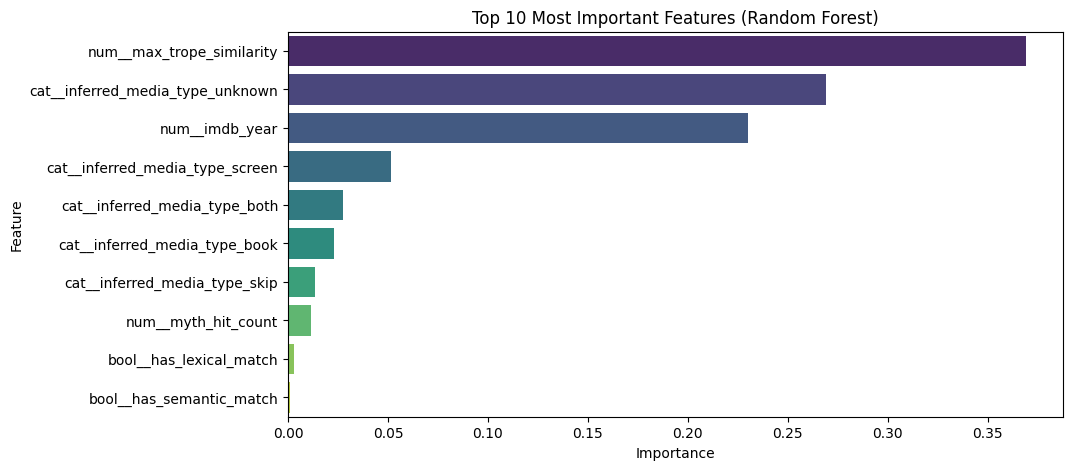

In [28]:
plt.figure(figsize=(10, 5))
sns.barplot(data=feat_imp.head(10), x="importance", y="feature", palette="viridis")
plt.title("Top 10 Most Important Features (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [ ]:

reduced_features = [
    "max_trope_similarity",
    "inferred_media_type",
    "imdb_year"
]

X_reduced = df[reduced_features]
y = df["myth_theme"]


numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

reduced_preprocessor = ColumnTransformer([
    ("num", numeric_pipe, ["max_trope_similarity", "imdb_year"]),
    ("cat", categorical_pipe, ["inferred_media_type"])
])

reduced_pipeline = Pipeline([
    ("preprocessor", reduced_preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=100, random_state=42))
])

scores = cross_val_score(reduced_pipeline, X_reduced, y, cv=5, scoring="f1_macro")
print(f"Reduced model F1 (macro): {scores.mean():.3f} ± {scores.std():.3f}")

Reduced model F1 (macro): 0.625 ± 0.049


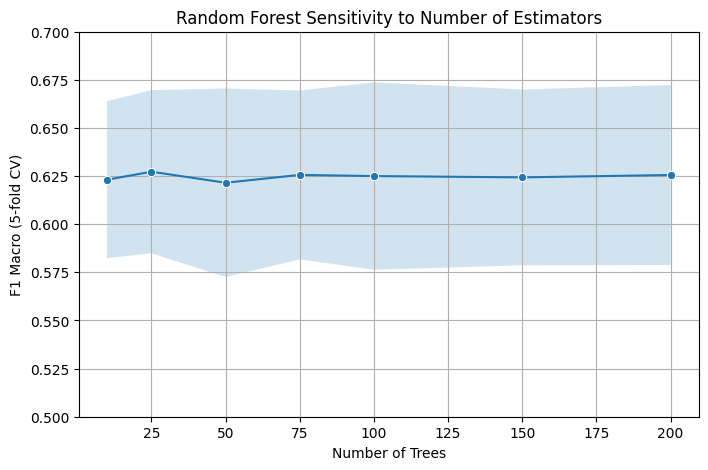

In [ ]:
#model is making almost all decisions based on max_trope_similarity, media type, and year

#hyperparameter tuning
n_estimators_range = [10, 25, 50, 75, 100, 150, 200]
results = []

for n in n_estimators_range:
    pipeline = Pipeline([
    ("preprocessor", reduced_preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=n, random_state=42))
])
    scores = cross_val_score(pipeline, X_reduced, y, cv=5, scoring="f1_macro")
    results.append({
        "n_estimators": n,
        "mean_f1": scores.mean(),
        "std_f1": scores.std()
    })


sensitivity_df = pd.DataFrame(results)


plt.figure(figsize=(8, 5))
sns.lineplot(data=sensitivity_df, x="n_estimators", y="mean_f1", marker="o")
plt.fill_between(
    sensitivity_df["n_estimators"],
    sensitivity_df["mean_f1"] - sensitivity_df["std_f1"],
    sensitivity_df["mean_f1"] + sensitivity_df["std_f1"],
    alpha=0.2
)
plt.title("Random Forest Sensitivity to Number of Estimators")
plt.xlabel("Number of Trees")
plt.ylabel("F1 Macro (5-fold CV)")
plt.ylim(0.5, 0.7)
plt.grid(True)
plt.show()

In [ ]:
#failure analysis
# Reuse the best model (Random Forest + reduced features)
X_train, X_test, y_train, y_test = train_test_split(
    X_reduced, y, test_size=0.2, stratify=y, random_state=42
)

# Fit on training data
reduced_pipeline.fit(X_train, y_train)


y_pred = reduced_pipeline.predict(X_test)


df_test = X_test.copy()
df_test["actual"] = y_test.values
df_test["predicted"] = y_pred
df_test["correct"] = df_test["actual"] == df_test["predicted"]


failures = df_test[df_test["correct"] == False]
failures.head()

,max_trope_similarity,inferred_media_type,imdb_year,actual,predicted,correct
1256,0.063054,both,1948.0,"Rebirth, Prophecy & Fate",Divine Conflict & Deific Representation,False
1332,0.000000,screen,2017.0,"Shapeshifters, Rebirth & Primal Archetypes","Rebirth, Prophecy & Fate",False
1194,0.036779,both,2019.0,Morally Grey: the Antihero’s Path,"Rebirth, Prophecy & Fate",False
1259,0.071534,screen,2013.0,Morally Grey: the Antihero’s Path,"Rebirth, Prophecy & Fate",False
1504,0.092921,both,2008.0,"Rebirth, Prophecy & Fate",Divine Conflict & Deific Representation,False


In [39]:
failures = failures.merge(df[["id", "combined_text", "type", "inferred_media_type", "myth_theme"]], 
                          left_index=True, right_index=True, how="left")

failures.head()

,max_trope_similarity,inferred_media_type_x,imdb_year,actual,predicted,correct,id,combined_text,type,inferred_media_type_y,myth_theme
1256,0.063054,both,1948.0,"Rebirth, Prophecy & Fate",Divine Conflict & Deific Representation,False,media_onetouchofvenus(film),One Touch of Venus One Touch of Venus In the a...,modern_media,both,"Rebirth, Prophecy & Fate"
1332,0.000000,screen,2017.0,"Shapeshifters, Rebirth & Primal Archetypes","Rebirth, Prophecy & Fate",False,media_marvelcinematicuniverse,The Marvel Cinematic Universe Analyzed,modern_media,screen,"Shapeshifters, Rebirth & Primal Archetypes"
1194,0.036779,both,2019.0,Morally Grey: the Antihero’s Path,"Rebirth, Prophecy & Fate",False,media_whatwedointheshadows(tvseries),HPI: What We Do in the Shadows In this excitin...,modern_media,both,Morally Grey: the Antihero’s Path
1259,0.071534,screen,2013.0,Morally Grey: the Antihero’s Path,"Rebirth, Prophecy & Fate",False,media_percyjackson:seaofmonsters,Percy Jackson: Sea of Monsters Percy Jackson r...,modern_media,screen,Morally Grey: the Antihero’s Path
1504,0.092921,both,2008.0,"Rebirth, Prophecy & Fate",Divine Conflict & Deific Representation,False,media_worldofquest,"The World of Quest In the land of Odyssia, for...",modern_media,both,"Rebirth, Prophecy & Fate"


In [50]:
print("X_reduced columns:", X_reduced.columns.tolist())
print("Failures columns:", failures.columns.tolist())

if "inferred_media_type_x" in failures.columns:
    failures = failures.drop(columns=["inferred_media_type_y"])
    failures = failures.rename(columns={"inferred_media_type_x": "inferred_media_type"})

X_reduced columns: ['max_trope_similarity', 'inferred_media_type', 'imdb_year']
Failures columns: ['max_trope_similarity', 'inferred_media_type', 'imdb_year', 'actual', 'predicted', 'correct', 'id', 'combined_text', 'type', 'myth_theme']


In [88]:
explainer = shap.TreeExplainer(reduced_pipeline.named_steps["classifier"])

chosen_instance = failures.iloc[[0]]
processed_instance = reduced_pipeline.named_steps["preprocessor"].transform(chosen_instance)

shap_values = explainer.shap_values(processed_instance)

feature_names = reduced_pipeline.named_steps["preprocessor"].get_feature_names_out()
print(reduced_pipeline.named_steps["classifier"].classes_)
print("explainer.expected_value:", explainer.expected_value)
print("len(shap_values):", len(shap_values))
print("shap_values shape:", shap_values.shape)

shap.initjs()
shap.force_plot(
    explainer.expected_value[1], 
    shap_values[0, :, 1], 
    processed_instance[0],
    feature_names=feature_names
)

['Divine Conflict & Deific Representation'
 'Morally Grey: the Antihero’s Path' 'Rebirth, Prophecy & Fate'
 'Shapeshifters, Rebirth & Primal Archetypes']
explainer.expected_value: [0.26897253 0.15181868 0.2321044  0.3471044 ]
len(shap_values): 1
shap_values shape: (1, 7, 4)


In [ ]:
def display_batch_shap_force_plots(
    explainer, 
    shap_values_batch, 
    X_transformed_batch, 
    feature_names, 
    pipeline, 
    failures_df
):
    shap.initjs()
    predictions = pipeline.named_steps["classifier"].predict(X_transformed_batch)
    class_list = list(pipeline.named_steps["classifier"].classes_)
    
    for i in range(X_transformed_batch.shape[0]):
        predicted_label = predictions[i]
        class_index = class_list.index(predicted_label)
        
        print(f"\nInstance {i} predicted as: {predicted_label} (Class Index: {class_index})")
        print(f"Actual: {failures_df.iloc[i]['actual']}")
        
        display(
            shap.plots.force(
                explainer.expected_value[class_index],
                shap_values_batch[class_index][i],
                feature_names=feature_names,
                matplotlib=True
            )
    )

1256    media_onetouchofvenus(film)
Name: id, dtype: object
explainer.expected_value: [0.26897253 0.15181868 0.2321044  0.3471044 ]


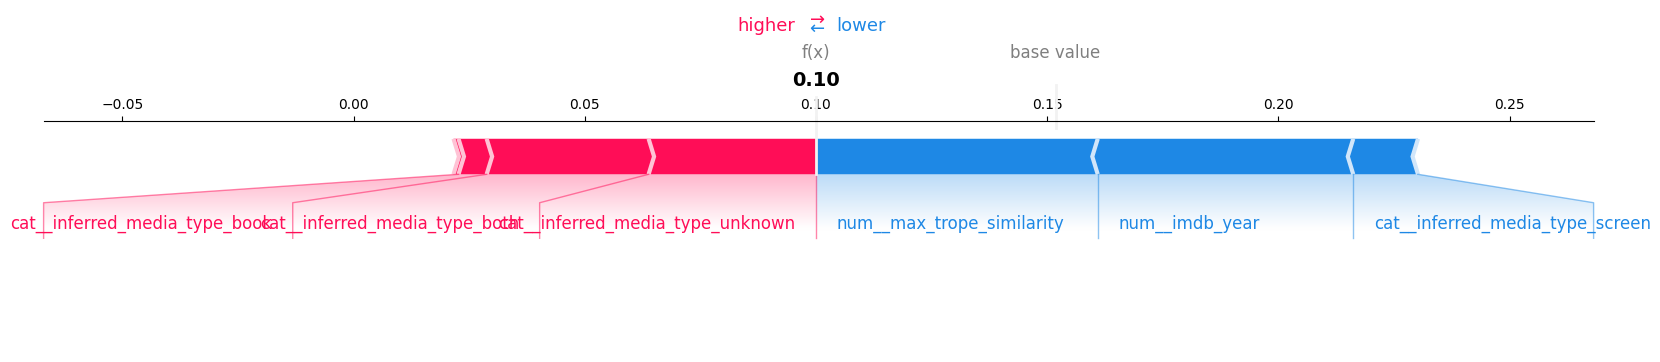

1332    media_marvelcinematicuniverse
Name: id, dtype: object
explainer.expected_value: [0.26897253 0.15181868 0.2321044  0.3471044 ]


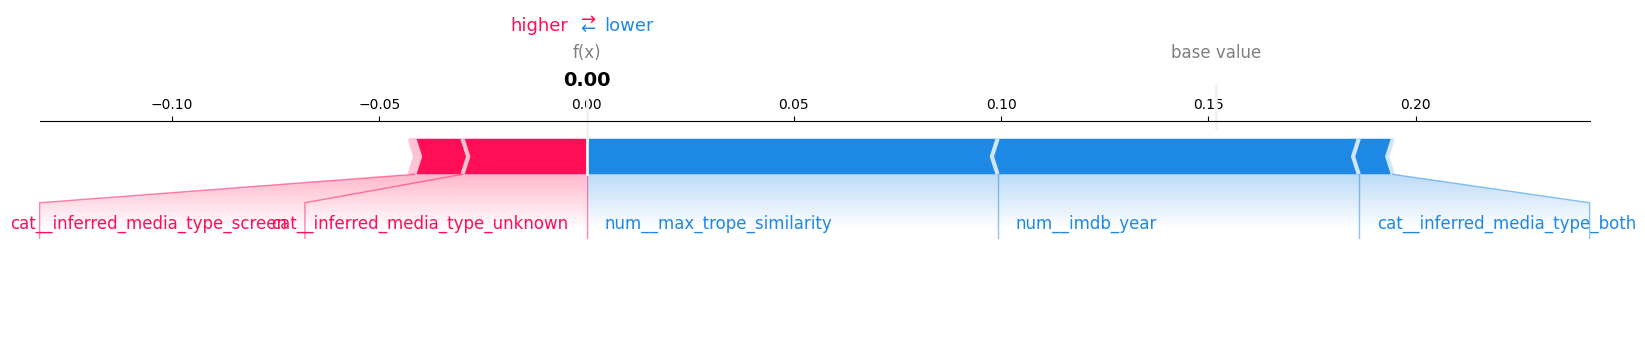

1194    media_whatwedointheshadows(tvseries)
Name: id, dtype: object
explainer.expected_value: [0.26897253 0.15181868 0.2321044  0.3471044 ]


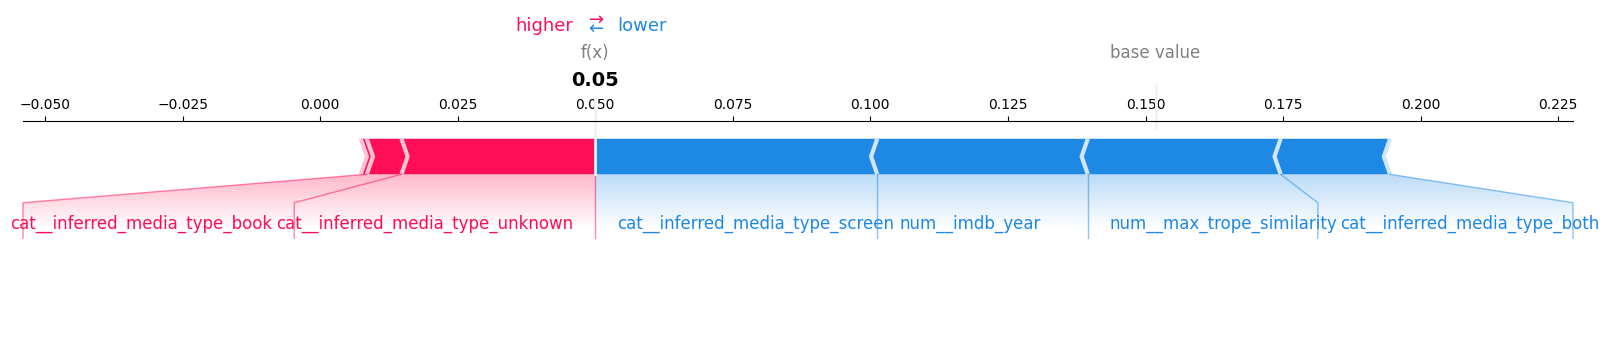

1259    media_percyjackson:seaofmonsters
Name: id, dtype: object
explainer.expected_value: [0.26897253 0.15181868 0.2321044  0.3471044 ]


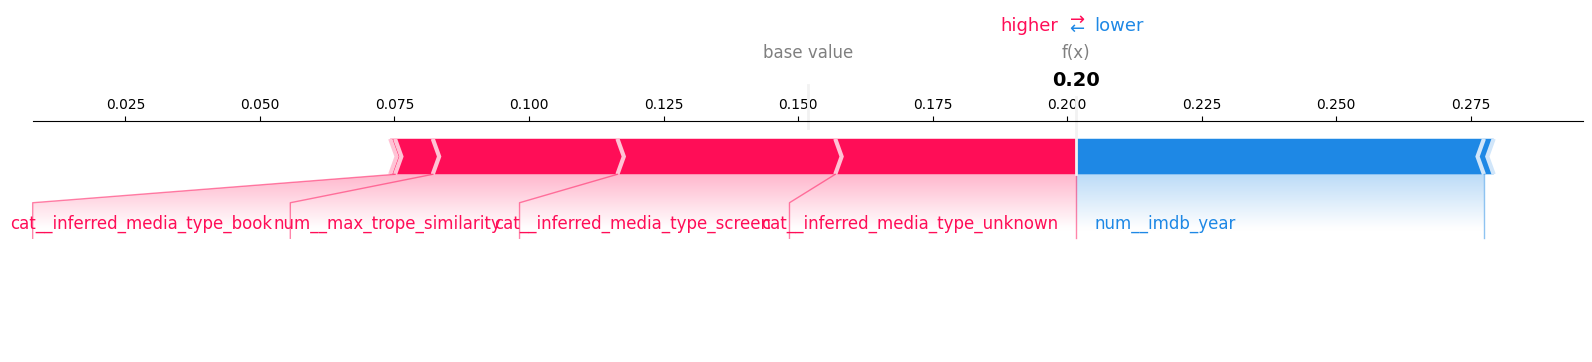

1504    media_worldofquest
Name: id, dtype: object
explainer.expected_value: [0.26897253 0.15181868 0.2321044  0.3471044 ]


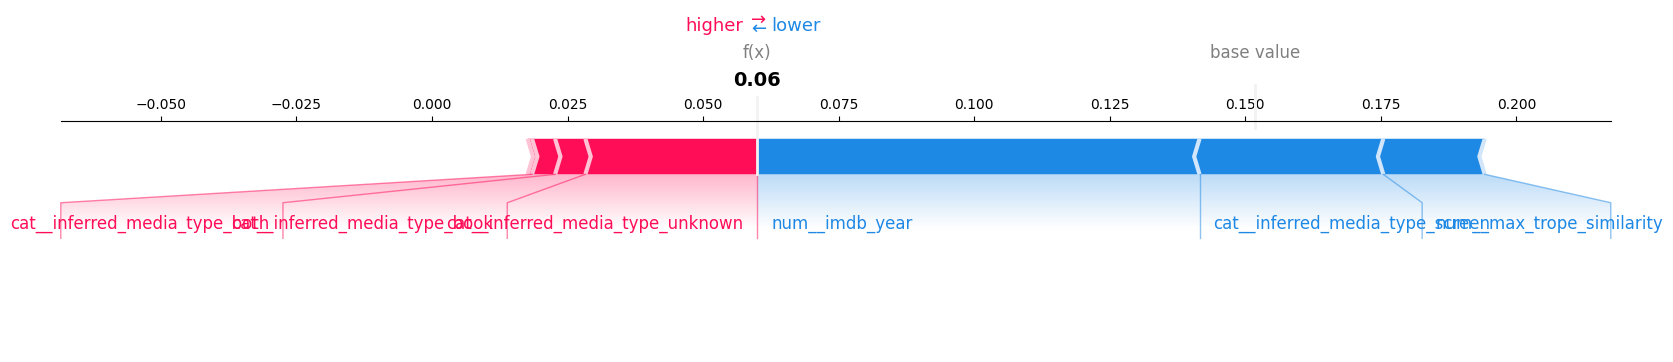

In [73]:
num_failures = 5

for i in range(0, num_failures):

    chosen_instance = failures.iloc[[i]]
    processed_instance = reduced_pipeline.named_steps["preprocessor"].transform(chosen_instance)

    shap_values = explainer.shap_values(processed_instance)

    feature_names = reduced_pipeline.named_steps["preprocessor"].get_feature_names_out()
    print(chosen_instance['id'])

    print("explainer.expected_value:", explainer.expected_value)



    shap.initjs()
    shap.force_plot(
        explainer.expected_value[1], 
        shap_values[0, :, 1],
        feature_names=feature_names,
        matplotlib=True 
        # processed_instance[0],
    )
    plt.show()

In [ ]:
X_reduced = df[["max_trope_similarity", "inferred_media_type", "imdb_year"]]
y_true = df["kmeans_cluster"]

X_train, X_test, y_train, y_test = train_test_split(
    X_reduced, y_true, test_size=0.2, random_state=42, stratify=y_true
)

pipeline_rf = Pipeline([
    ("preprocessor", reduced_preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

pipeline_rf.fit(X_train, y_train)
y_pred = pipeline_rf.predict(X_test)

In [75]:
ari_rf_reduced = adjusted_rand_score(y_test, y_pred)
print(f"Random Forest ARI (Reduced Features): {ari_rf_reduced:.3f}")


Random Forest ARI (Reduced Features): 0.962


In [ ]:
feature_cols_full = [col for col in df.columns if col not in ["cluster", "kmeans_cluster", "agglo_cluster", "id", "text", "combined_text", "source", "type", "myth_theme", "predicted", "actual", "correct"]]

X_full = df[feature_cols_full]
y_true = df["kmeans_cluster"]

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_true, test_size=0.2, random_state=42, stratify=y_true
)


pipeline_rf_full = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

pipeline_rf_full.fit(X_train, y_train)
y_pred_full = pipeline_rf_full.predict(X_test)

ari_rf_full = adjusted_rand_score(y_test, y_pred_full)
print(f"Random Forest ARI (Full Features): {ari_rf_full:.3f}")

Random Forest ARI (Full Features): 0.983


In [ ]:
feature_cols_full = [col for col in df.columns if col not in [
    "cluster", "kmeans_cluster", "agglo_cluster", 
    "id", "text", "combined_text", "source", "type", 
    "myth_theme", "predicted", "actual", "correct"
]]

X_full = df[feature_cols_full]
y = df["kmeans_cluster"]

1271    1
2187    0
2088    3
981     1
2161    3
2257    0
178     1
531     3
1574    1
1702    0
Name: kmeans_cluster, dtype: int32


In [81]:
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y, test_size=0.2, random_state=42, stratify=y
)

In [84]:
numeric_features = X_full.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_full.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

full_preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [ ]:
rf_failures = failures.drop(columns=X.columns, errors='ignore').merge(
    df[X.columns],
    left_index=True,
    right_index=True,
    how="left"
)

print(rf_failures.columns)

rf_explainer = shap.TreeExplainer(rf_pipeline.named_steps["clf"])

rf_chosen_instance = rf_failures.iloc[[0]]
rf_processed_instance = rf_pipeline.named_steps["preprocess"].transform(rf_chosen_instance)

rf_shap_values = rf_explainer.shap_values(rf_processed_instance)

rf_feature_names = rf_pipeline.named_steps["preprocess"].get_feature_names_out()
print(rf_pipeline.named_steps["clf"].classes_)
print("explainer.expected_value:", rf_explainer.expected_value)
print("len(shap_values):", len(rf_shap_values))
print("shap_values shape:", rf_shap_values.shape)

shap.initjs()
shap.force_plot(
    rf_explainer.expected_value[1], 
    rf_shap_values[0, :, 1], 
    rf_processed_instance[0],
    feature_names=rf_feature_names
)

Index(['actual', 'predicted', 'correct', 'id', 'combined_text', 'type',
       'myth_theme', 'myth_hit_count', 'max_trope_similarity', 'imdb_year',
       'inferred_media_type', 'has_lexical_match', 'has_semantic_match',
       'has_sentence_myth_trope_hit'],
      dtype='object')
[0 1 2 3]
explainer.expected_value: [0.41101538 0.38603956 0.02276923 0.18017582]
len(shap_values): 1
shap_values shape: (1, 11, 4)


1256    media_onetouchofvenus(film)
Name: id, dtype: object
explainer.expected_value: [0.26897253 0.15181868 0.2321044  0.3471044 ]


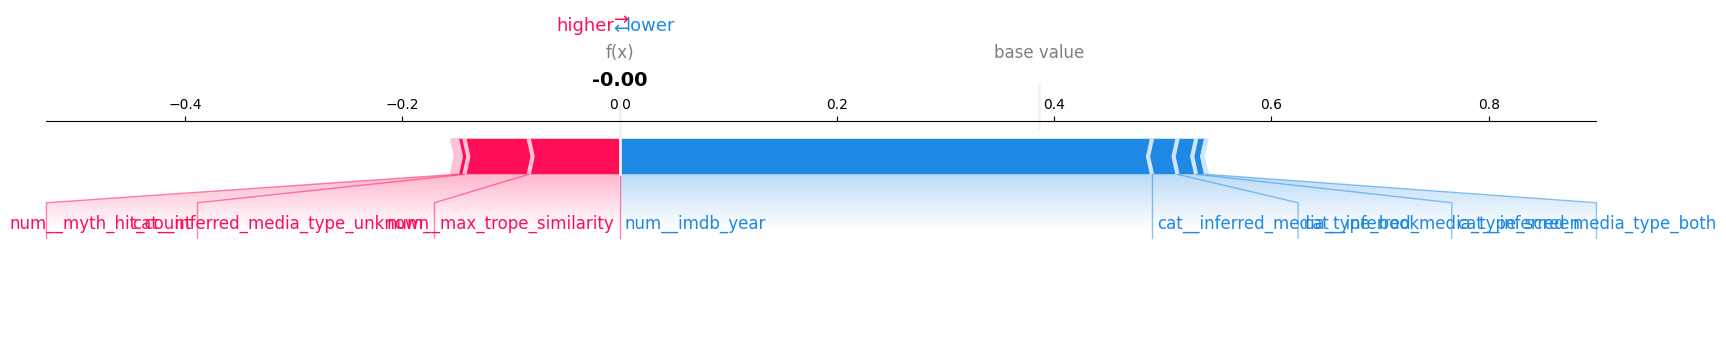

1256    media_onetouchofvenus(film)
Name: id, dtype: object
explainer.expected_value: [0.26897253 0.15181868 0.2321044  0.3471044 ]


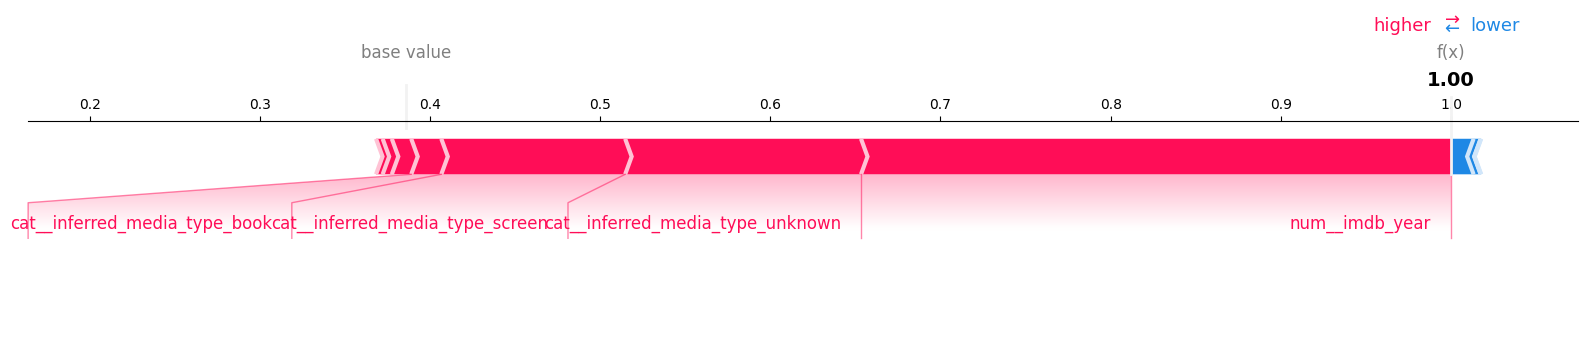

1256    media_onetouchofvenus(film)
Name: id, dtype: object
explainer.expected_value: [0.26897253 0.15181868 0.2321044  0.3471044 ]


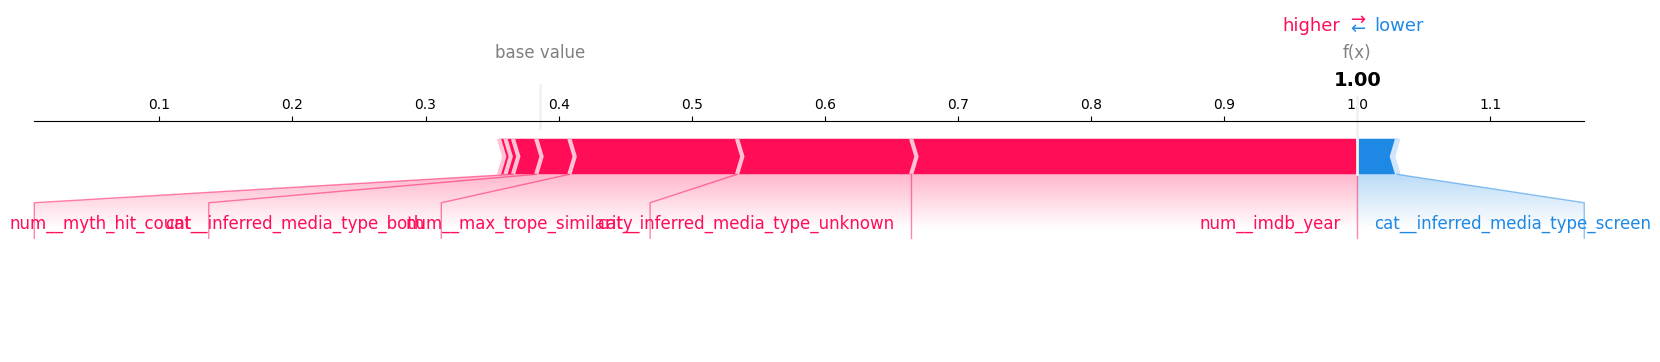

1256    media_onetouchofvenus(film)
Name: id, dtype: object
explainer.expected_value: [0.26897253 0.15181868 0.2321044  0.3471044 ]


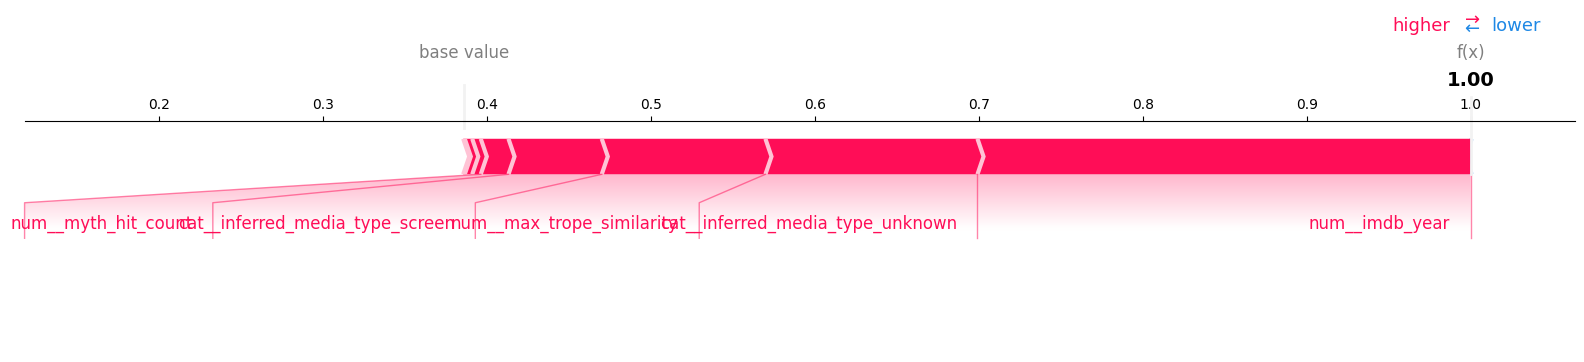

1256    media_onetouchofvenus(film)
Name: id, dtype: object
explainer.expected_value: [0.26897253 0.15181868 0.2321044  0.3471044 ]


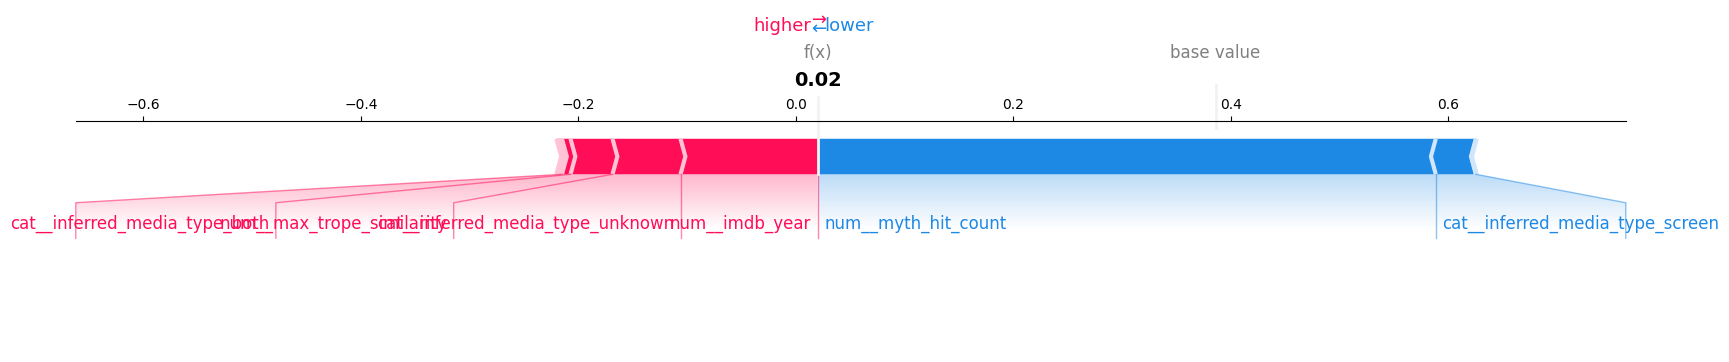

In [95]:
num_failures = 5

for i in range(0, num_failures):


    rf_chosen_instance = rf_failures.iloc[[i]]
    rf_processed_instance = rf_pipeline.named_steps["preprocess"].transform(rf_chosen_instance)

    rf_shap_values = rf_explainer.shap_values(rf_processed_instance)

    rf_feature_names = rf_pipeline.named_steps["preprocess"].get_feature_names_out()
    print(chosen_instance['id'])
    print("explainer.expected_value:", explainer.expected_value)

    shap.initjs()
    shap.force_plot(
        rf_explainer.expected_value[1], 
        rf_shap_values[0, :, 1], 
        #rf_processed_instance[0],
        feature_names=rf_feature_names,
        matplotlib=True
    )
    plt


In [99]:
num_failures = 5 
batch_failures = rf_failures.iloc[:num_failures]
processed_failures = rf_pipeline.named_steps["preprocess"].transform(batch_failures)
rf_shap_values = rf_explainer.shap_values(processed_failures)
rf_feature_names = rf_pipeline.named_steps["preprocess"].get_feature_names_out()
predictions = rf_pipeline.named_steps["clf"].predict(processed_failures)
true_labels = batch_failures["actual"].values

for i in range(num_failures):
    print(f"\nInstance {i}")
    print(f"Predicted: {predictions[i]}")
    print(f"Actual: {true_labels[i]}")


Instance 0
Predicted: 3
Actual: Rebirth, Prophecy & Fate

Instance 1
Predicted: 1
Actual: Shapeshifters, Rebirth & Primal Archetypes

Instance 2
Predicted: 1
Actual: Morally Grey: the Antihero’s Path

Instance 3
Predicted: 1
Actual: Morally Grey: the Antihero’s Path

Instance 4
Predicted: 2
Actual: Rebirth, Prophecy & Fate


(455, 11)
Before fix: (11, 4)
After fix: (4, 11)


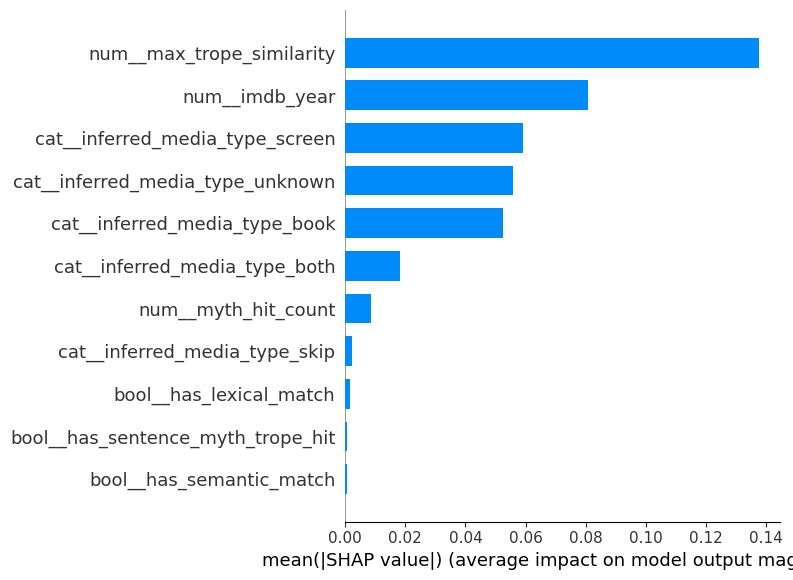

In [ ]:
rf_explainer = shap.TreeExplainer(rf_pipeline.named_steps["clf"])

X_test_transformed = rf_pipeline.named_steps["preprocess"].transform(X_test)

print(X_test_transformed.shape) 

if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()


rf_feature_names = rf_pipeline.named_steps["preprocess"].get_feature_names_out()


rf_shap_values = rf_explainer.shap_values(X_test_transformed)

print("Before fix:", rf_shap_values[0].shape)
if rf_shap_values[0].shape[0] != X_test_transformed.shape[0]:
    rf_shap_values = [sv.T for sv in rf_shap_values]
print("After fix:", rf_shap_values[0].shape)


class_index = 0  


shap.summary_plot(
    rf_shap_values[class_index],      
    X_test_transformed,               
    feature_names=rf_feature_names,   
    plot_type="bar"                   
)

After fix: (4, 11)

SHAP Summary Plot for Class: 0 (Index: 0)


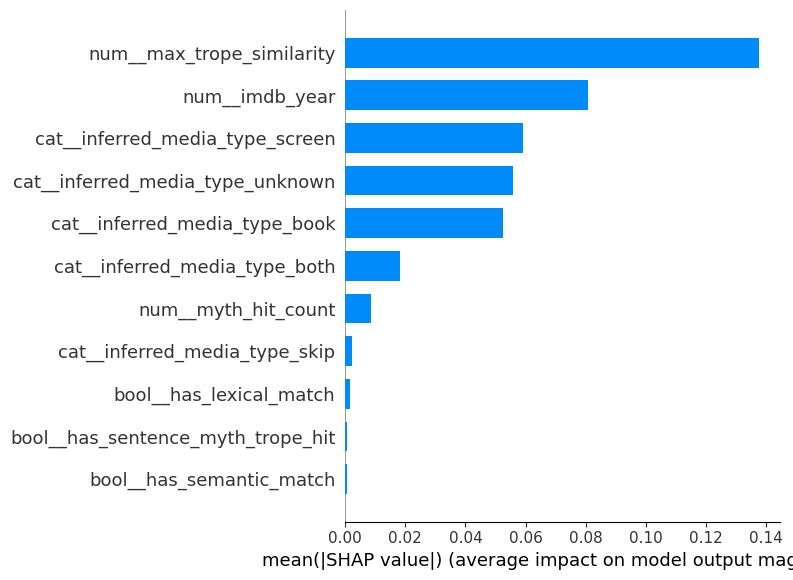


SHAP Summary Plot for Class: 1 (Index: 1)


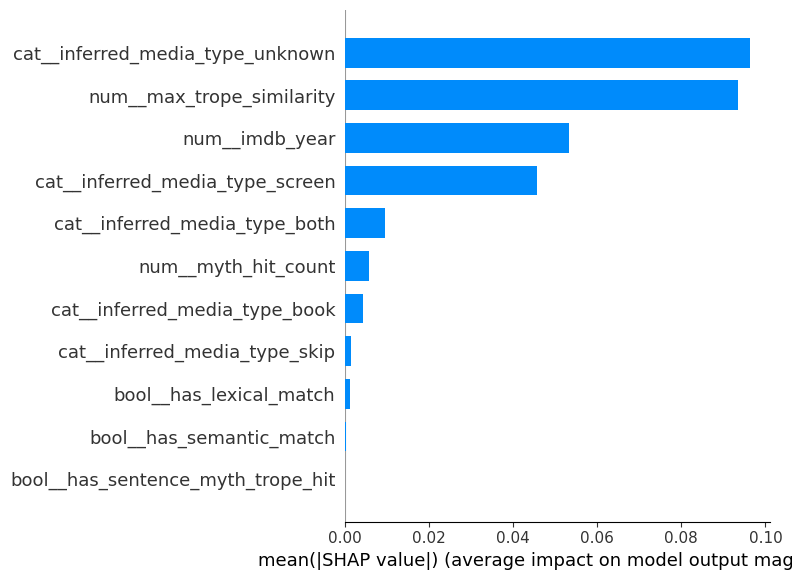


SHAP Summary Plot for Class: 2 (Index: 2)


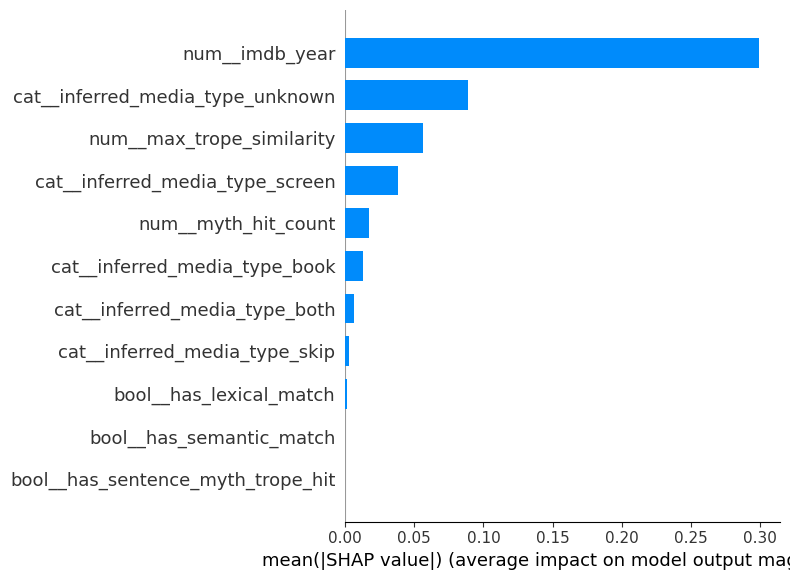


SHAP Summary Plot for Class: 3 (Index: 3)


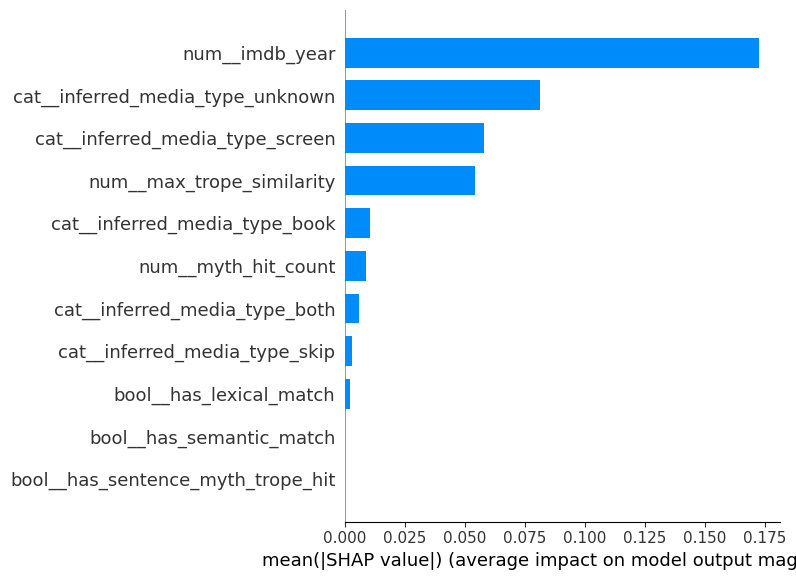

In [ ]:

rf_explainer = shap.TreeExplainer(rf_pipeline.named_steps["clf"])
X_test_transformed = rf_pipeline.named_steps["preprocess"].transform(X_test)
if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

rf_feature_names = rf_pipeline.named_steps["preprocess"].get_feature_names_out()
rf_shap_values = rf_explainer.shap_values(X_test_transformed)

if rf_shap_values[0].shape[0] != X_test_transformed.shape[0]:
    rf_shap_values = [sv.T for sv in rf_shap_values]
print("After fix:", rf_shap_values[0].shape)


class_labels = rf_pipeline.named_steps["clf"].classes_

for class_index, label in enumerate(class_labels):
    print(f"\nSHAP Summary Plot for Class: {label} (Index: {class_index})")
    shap.summary_plot(
        rf_shap_values[class_index],
        X_test_transformed,
        feature_names=rf_feature_names,
        plot_type="bar",
        show=True
    )

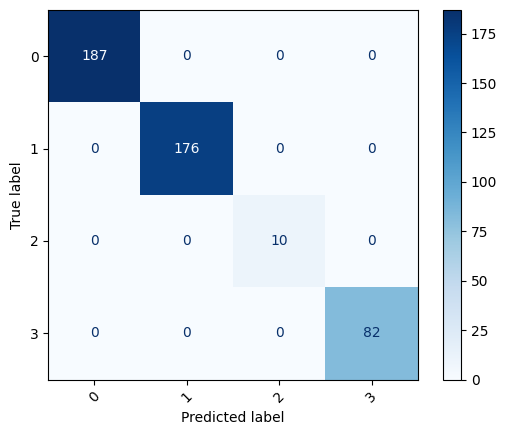

In [ ]:

y_pred = rf_pipeline.predict(X_test)


cm = confusion_matrix(y_test, y_pred, labels=class_labels)


disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(cmap="Blues", xticks_rotation=45)

In [ ]:

features = [
    "max_trope_similarity",
    "imdb_year",
    "inferred_media_type",
    "has_lexical_match",
    "has_semantic_match",
    "has_myth_hit",
    "has_myth_trope_hit",
    "myth_hit_count"
]

X_myth = df[features]
y_myth = df["kmeans_cluster"] 

X_train, X_test, y_train, y_test = train_test_split(
    X_myth,
    y_myth,
    test_size=0.2,
    stratify=y_myth,
    random_state=42
)


numeric_features = ["max_trope_similarity", "imdb_year", "myth_hit_count"]
categorical_features = ["inferred_media_type"]
boolean_features = ["has_lexical_match", "has_semantic_match", "has_myth_hit", "has_myth_trope_hit"]


numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])


myth_preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
    ("bool", "passthrough", boolean_features)
])

rf_pipeline_myth = Pipeline([
    ("preprocessor", myth_preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=100, random_state=42))
])


rf_pipeline_myth.fit(X_train, y_train)


print(f"Train Accuracy: {rf_pipeline_myth.score(X_train, y_train):.3f}")
print(f"Test Accuracy: {rf_pipeline_myth.score(X_test, y_test):.3f}")

Train Accuracy: 1.000
Test Accuracy: 0.991


In [125]:
y_pred = rf_pipeline_myth.predict(X_test)
ari = adjusted_rand_score(y_test, y_pred)
print(f"Adjusted Rand Index (ARI): {ari:.3f}")

Adjusted Rand Index (ARI): 0.978


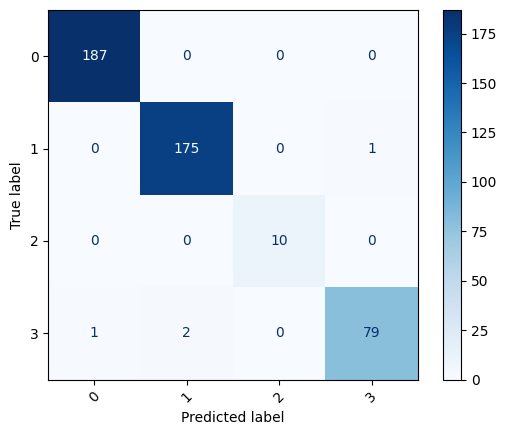

In [126]:
cm = confusion_matrix(y_test, y_pred, labels=rf_pipeline_myth.named_steps["classifier"].classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_pipeline_myth.named_steps["classifier"].classes_)
disp.plot(cmap="Blues", xticks_rotation=45)